# Alternatives to the Lennard-Jones potential

### Filippo Barbari - 11045039


In [141]:
# Importing libraries
import numpy as np
import matplotlib.pyplot as plt

## The Lennard-Jones potential
The LJ potential is an interatomic potential mainly used to model interactions between neutral atoms or apolar molecules.

$V_{LJ}(r) = 4\varepsilon \left[ \left( \frac{\sigma}{r} \right)^{12} - \left( \frac{\sigma}{r} \right)^6 \right]$

Proposed in 1924 by ..., it has been widely adopted (TODO: insert number of citations of the original article) because of N main reasons:
- it can model both the Pauli repulsion and the London dispersion/attraction
- it is relatively simple to formulate and compute: it depends only one parameter, the euclidean distance between the interacting particles

Since it depends solely on the euclidean distance, which is spherically symmetric, the LJ potential is itself spherically symmetric.

It depends on two parameters, $\sigma$ and $\varepsilon$, which model the "spread" of the potential (and therefore the location of its only minimum) and the scale of the output value, respectively.

Its only minimum is exactly at $r_{min} = 2^{\frac{1}{6}} \sigma$.

However, it's not the first (nor the best) kind of interatomic potential which has these properties.

...


In [142]:
def lennard_jones(r, sigma=1.0, epsilon=1.0):
    return 4 * epsilon * ((sigma / r) ** 12 - (sigma / r) ** 6)

<>:51: SyntaxWarning: invalid escape sequence '\s'
<>:51: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_239931/4214903686.py:51: SyntaxWarning: invalid escape sequence '\s'
  "Lennard-Jones Potential for Different $\sigma$ and $\epsilon$", fontsize=16


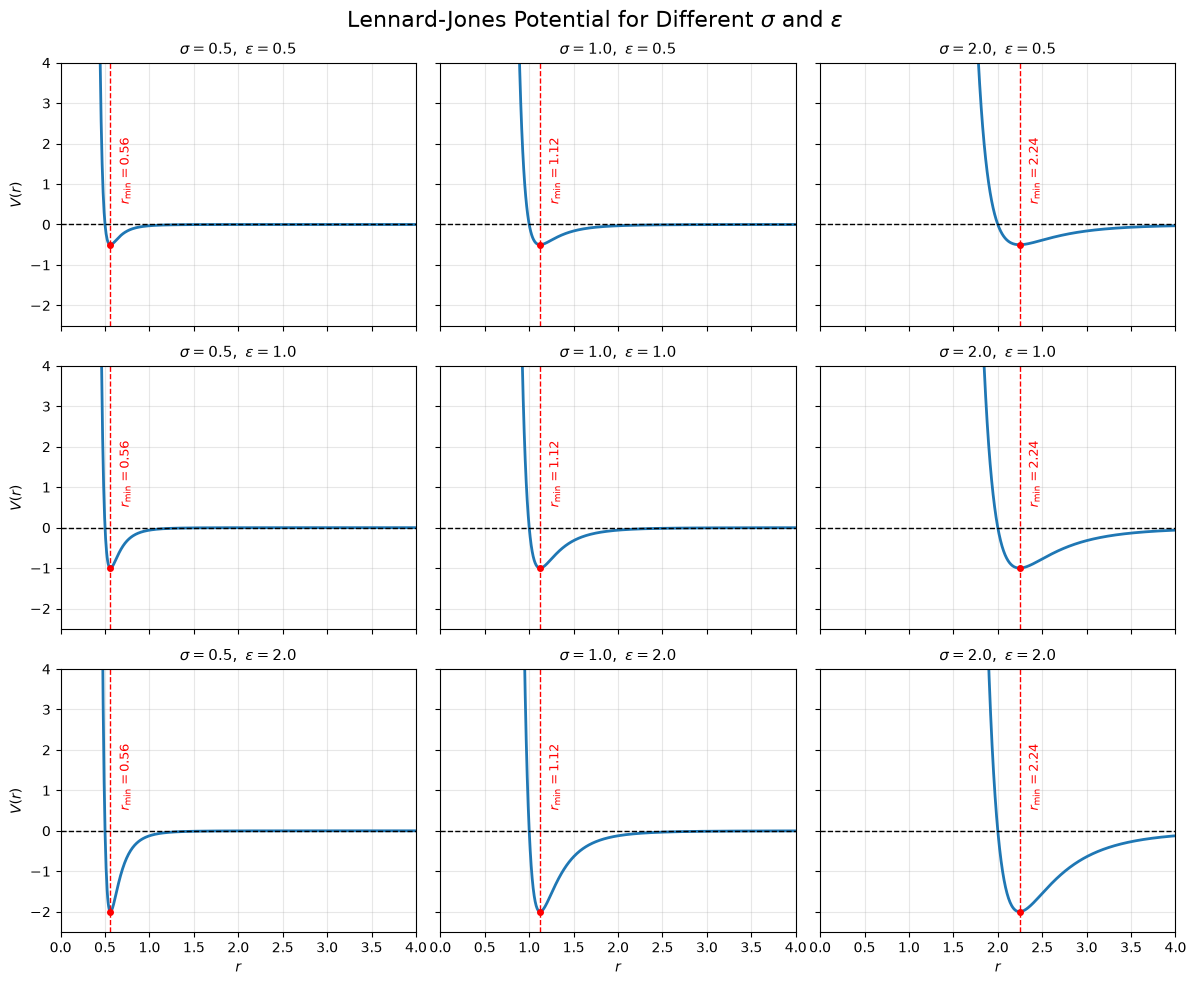

In [143]:
sigma_values = [0.5, 1.0, 2.0]
epsilon_values = [0.5, 1.0, 2.0]

r = np.linspace(0.4, 6.0, 1000)

fig, axes = plt.subplots(
    len(epsilon_values), len(sigma_values), figsize=(12, 10), sharex=True, sharey=True
)

xlim = (0.0, 4.0)
ylim = (-2.5, 4.0)

for i, epsilon in enumerate(epsilon_values):
    for j, sigma in enumerate(sigma_values):
        ax = axes[i, j]

        V = lennard_jones(r, sigma, epsilon)
        ax.plot(r, V, linewidth=2, label="LJ potential")

        r_min = 2 ** (1 / 6) * sigma
        V_min = -epsilon

        ax.axhline(0, color="black", linestyle="--", linewidth=1)

        ax.axvline(r_min, color="red", linestyle="--", linewidth=1)

        ax.plot(r_min, V_min, "ro", markersize=4)

        ax.text(
            r_min + 0.1,
            0.5,
            rf"$r_{{\min}}={r_min:.2f}$",
            rotation=90,
            color="red",
            fontsize=9,
            ha="left",
            va="bottom",
        )

        ax.set_title(rf"$\sigma={sigma},\ \epsilon={epsilon}$", fontsize=11)
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.grid(True, alpha=0.3)

        if i == len(epsilon_values) - 1:
            ax.set_xlabel(r"$r$")
        if j == 0:
            ax.set_ylabel(r"$V(r)$")

fig.suptitle(
    "Lennard-Jones Potential for Different $\sigma$ and $\epsilon$", fontsize=16
)
plt.tight_layout()
plt.show()

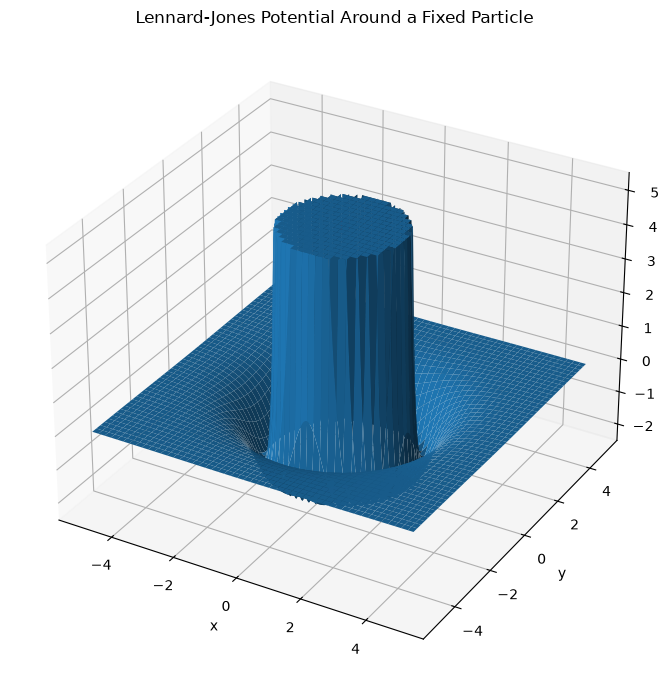

In [144]:
x = np.linspace(-5.0, 5.0, 300)
y = np.linspace(-5.0, 5.0, 300)

X, Y = np.meshgrid(x, y)

# Distance from the fixed particle at the origin
R = np.sqrt(X**2 + Y**2)

# Avoid division by zero
R[R < 0.8 * sigma] = 0.8 * sigma

# Lennard-Jones potential
U = 4 * epsilon * ((sigma / R) ** 12 - (sigma / R) ** 6)

# Clip the repulsive wall for visualization
U = np.clip(U, -2.0, 5)

# Plot
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    X,
    Y,
    U,
    # cmap="viridis",
    linewidth=0,
    antialiased=True,
)

# Mark the fixed particle
ax.scatter(0, 0, 5, color="red", s=80, label="Fixed particle")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("Lennard-Jones Potential")
ax.set_title("Lennard-Jones Potential Around a Fixed Particle")
# fig.colorar(surf, shrink=0.6, label="Potential")
# ax.legend()
plt.tight_layout()
plt.show()

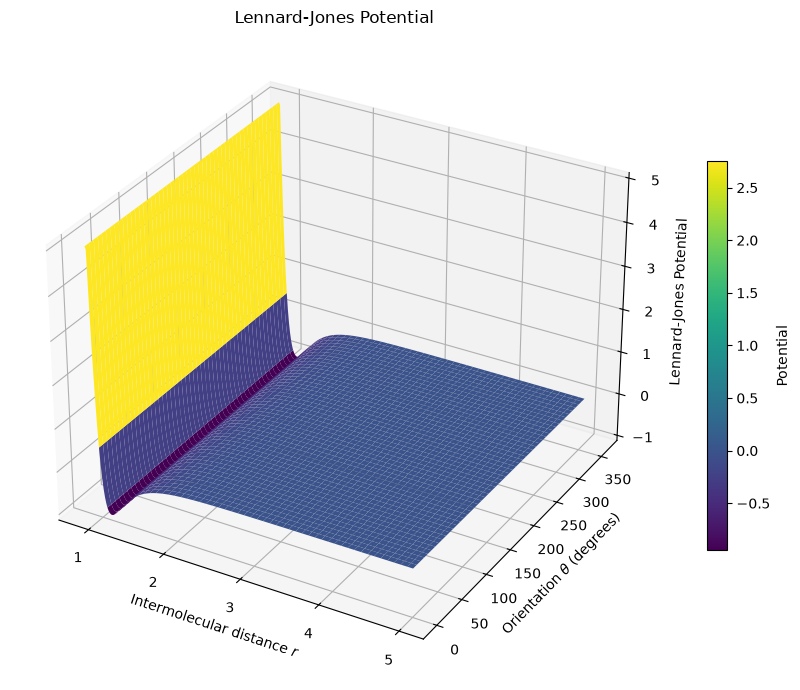

In [145]:
# Parameter space
r = np.linspace(0.9, 5.0, 300)
theta = np.linspace(0, 2 * np.pi, 300)

R, THETA = np.meshgrid(r, theta)

# Potential (independent of theta)
U = lennard_jones(R)

# Clip for visualization
U = np.clip(U, -2, 5)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    R,
    np.degrees(THETA),
    U,
    cmap="viridis",
    edgecolor="none",
)

ax.set_xlabel("Intermolecular distance $r$")
ax.set_ylabel("Orientation $\\theta$ (degrees)")
ax.set_zlabel("Lennard-Jones Potential")
ax.set_title("Lennard-Jones Potential")

fig.colorbar(surf, shrink=0.6, label="Potential")

plt.tight_layout()
plt.show()

## The Gay-Berne potential

LAMMPS implementation can be found here: https://github.com/lammps/lammps/blob/develop/src/ASPHERE/pair_gayberne.cpp

$U_{GB}(r, \hat{u}_1, \hat{u}_2) = 4 \varepsilon(\hat{u}_1, \hat{u}_2, \hat{r}) \left[ \left( \frac{\sigma_0}{r - \sigma(\hat{u}_1, \hat{u}_2, \hat{r}) + \sigma_0} \right)^{12} - \left( \frac{\sigma_0}{r - \sigma(\hat{u}_1, \hat{u}_2, \hat{r}) + \sigma_0} \right)^{6} \right]$

With:
- $r$: the distance between molecular centers
- $\hat{r}$: the unit vector along the intermolecular separation
- $\hat{u}_1$ and $\hat{u}_2$ being the orientations of the two ellipsoids
- $\sigma_0$: minimum molecular diameter
- $\sigma(\dots)$: orientation-dependent contact distance
- $\varepsilon(\dots)$: orientation-dependent well-depth

A common explicit parametrization is:

$
\sigma(\hat{u}_1, \hat{u}_2, \hat{r}) =
\sigma_0 \left[
1 - \frac{\chi}{2}
\left(
\frac{(\hat{r}\cdot \hat{u}_1 + \hat{r}\cdot \hat{u}_2)^2}{1 + \chi\, \hat{u}_1\cdot \hat{u}_2}
+
\frac{(\hat{r}\cdot \hat{u}_1 - \hat{r}\cdot \hat{u}_2)^2}{1 - \chi\, \hat{u}_1\cdot \hat{u}_2}
\right)
\right]^{-1/2}
$

$
\varepsilon(\hat{u}_1, \hat{u}_2, \hat{r}) =
\varepsilon_0 \left[1 - \chi^2 (\hat{u}_1\cdot \hat{u}_2)\right]^{-\nu/2}
\left[
1 - \frac{\chi'}{2}
\left(
\frac{(\hat{r}\cdot \hat{u}_1 + \hat{r}\cdot \hat{u}_2)^2}{1 + \chi'\, \hat{u}_1\cdot \hat{u}_2}
+
\frac{(\hat{r}\cdot \hat{u}_1 - \hat{r}\cdot \hat{u}_2)^2}{1 - \chi'\, \hat{u}_1\cdot \hat{u}_2}
\right)
\right]^{\mu}
$

$\varepsilon_0$: reference energy

$\chi = \frac{\kappa^2 - 1}{\kappa^2 + 1}$

$\chi' = \frac{\kappa^{1/\mu} - 1}{\kappa^{1/\mu} + 1}$

$\kappa = \frac{\sigma_e}{\sigma_s}$ is the molecular aspect ratio

$\sigma_e$ is the end-to-end diameter

$\sigma_s$ is the side-by-side diameter

Usually, $\kappa=3$, $\kappa'=5$, $\mu=2$ and $\nu=1$.


In [146]:
k = 3.0
k_prime = 5.0
mu = 2.0
nu = 1.0
chi = (k**2 - 1.0) / (k**2 + 1.0)
chi_prime = (k_prime ** (1.0 / mu) - 1.0) / (k_prime ** (1.0 / mu) + 1.0)


def contact_distance(u1_hat, u2_hat, r_hat, sigma0=1.0):
    r_u1 = r_hat.dot(u1_hat)
    r_u2 = r_hat.dot(u2_hat)
    u1_u2 = u1_hat.dot(u2_hat)
    return (
        sigma0
        * (
            1.0
            - (chi / 2.0)
            * (
                ((r_u1 + r_u2) ** 2 / (1.0 + chi * u1_u2))
                + ((r_u1 - r_u2) ** 2 / (1.0 - chi * u1_u2))
            )
        )
        ** -0.5
    )


def well_depth(u1_hat, u2_hat, r_hat, epsilon0=1.0):
    r_u1 = r_hat.dot(u1_hat)
    r_u2 = r_hat.dot(u2_hat)
    u1_u2 = u1_hat.dot(u2_hat)
    return (
        epsilon0
        * (1.0 - chi_prime**2 * u1_u2) ** (-nu / 2.0)
        * (
            1.0
            - (chi_prime / 2.0)
            * (
                ((r_u1 + r_u2) ** 2 / (1.0 + chi_prime * u1_u2))
                + ((r_u1 - r_u2) ** 2 / (1.0 - chi_prime * u1_u2))
            )
        )
        ** mu
    )


# General formulation
def gay_berne_general_cartesian(r_v, u1_hat, u2_hat, sigma0=1.0):
    # assert r_v.shape == (3,)
    # assert abs(np.linalg.norm(u1_hat) - 1.0) < 1e-6
    # assert abs(np.linalg.norm(u2_hat) - 1.0) < 1e-6
    r = np.linalg.norm(r_v)
    r_hat = r_v / r
    r_star = sigma0 / (r - contact_distance(u1_hat, u2_hat, r_hat) + sigma0)
    return 4.0 * well_depth(u1_hat, u2_hat, r_hat) * (r_star**12 - r_star**6)

In [147]:
def contact_distance(theta, delta_phi, sigma0=1.0):
    r_u1 = np.cos(theta)
    r_u2 = np.cos(theta - delta_phi)
    u1_u2 = np.cos(delta_phi)

    return sigma0 / np.sqrt(
        1.0
        - (chi / 2.0)
        * (
            (r_u1 + r_u2) ** 2 / (1.0 + chi * u1_u2)
            + (r_u1 - r_u2) ** 2 / (1.0 - chi * u1_u2)
        )
    )


def well_depth(theta, delta_phi, epsilon0=1.0):
    r_u1 = np.cos(theta)
    r_u2 = np.cos(theta - delta_phi)
    u1_u2 = np.cos(delta_phi)

    eps1 = (1.0 - chi**2 * u1_u2**2) ** (-nu / 2.0)

    eps2 = (
        1.0
        - (chi_prime / 2.0)
        * (
            (r_u1 + r_u2) ** 2 / (1.0 + chi_prime * u1_u2)
            + (r_u1 - r_u2) ** 2 / (1.0 - chi_prime * u1_u2)
        )
    ) ** mu

    return epsilon0 * eps1 * eps2


def gay_berne_general_polar(r, theta, delta_phi, sigma0=1.0):
    sigma = contact_distance(theta, delta_phi, sigma0)
    epsilon = well_depth(theta, delta_phi)

    rho = sigma0 / (r - sigma + sigma0)

    return 4.0 * epsilon * (rho**12 - rho**6)

In [148]:
print(
    gay_berne_general_cartesian(
        np.array((2.0, 0.0, 0.0)),
        np.array((1.0, 0.0, 0.0)),
        np.array((0.0, 1.0, 0.0)),
    )
)

print(
    gay_berne_general_polar(
        np.sqrt(2.0**2 + 0.0**2 + 0.0**2),
        0.0,
        np.pi / 2.0,
    )
)

[-0.11848555 -0.         -0.        ]
30.987812826513235


In [149]:
if False:
    r_ticks = 1000
    theta_ticks = 1000

    r = np.linspace(0.0, 5.0, r_ticks)
    theta = np.linspace(0.0, 2.0 * np.pi, theta_ticks)

    R, THETA = np.meshgrid(r, theta)

    u_1 = np.array((1.0, 0.0, 0.0))

    u_2 = np.stack(
        (
            np.cos(THETA),
            np.sin(THETA),
            np.zeros_like(THETA),
        ),
        axis=-1,
    )

    # U = np.zeros(
    #     (
    #         r_ticks,
    #         theta_ticks,
    #     )
    # )
    # for i in range(r_ticks):
    #     r_v = np.stack(
    #         (
    #             r[i],
    #             np.zeros_like(r[i]),
    #             np.zeros_like(r[i]),
    #         ),
    #         axis=-1,
    #     )
    #     for j in range(theta_ticks):
    #         u_2 = np.stack(
    #             (
    #                 np.cos(theta[j]),
    #                 np.sin(theta[j]),
    #                 np.zeros_like(theta[j]),
    #             ),
    #             axis=-1,
    #         )
    #         U[i, j] = np.clip(
    #             gay_berne_general(r_v, u_1, u_2),
    #             -2.0,
    #             5.0,
    #         )

    U = gay_berne_general_cartesian(R, u_1, u_2)
    U = np.clip(U, -2, 5)

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")

    surf = ax.plot_surface(R, THETA * 180 / np.pi, U, cmap="viridis", edgecolor="none")

    ax.set_xlabel("Intermolecular distance r")
    ax.set_ylabel("Relative orientation θ (degrees)")
    ax.set_zlabel("Gay-Berne Potential")

    ax.set_title("Gay-Berne Potential")

    fig.colorbar(surf, shrink=0.6, label="Potential")

    plt.tight_layout()
    plt.show()

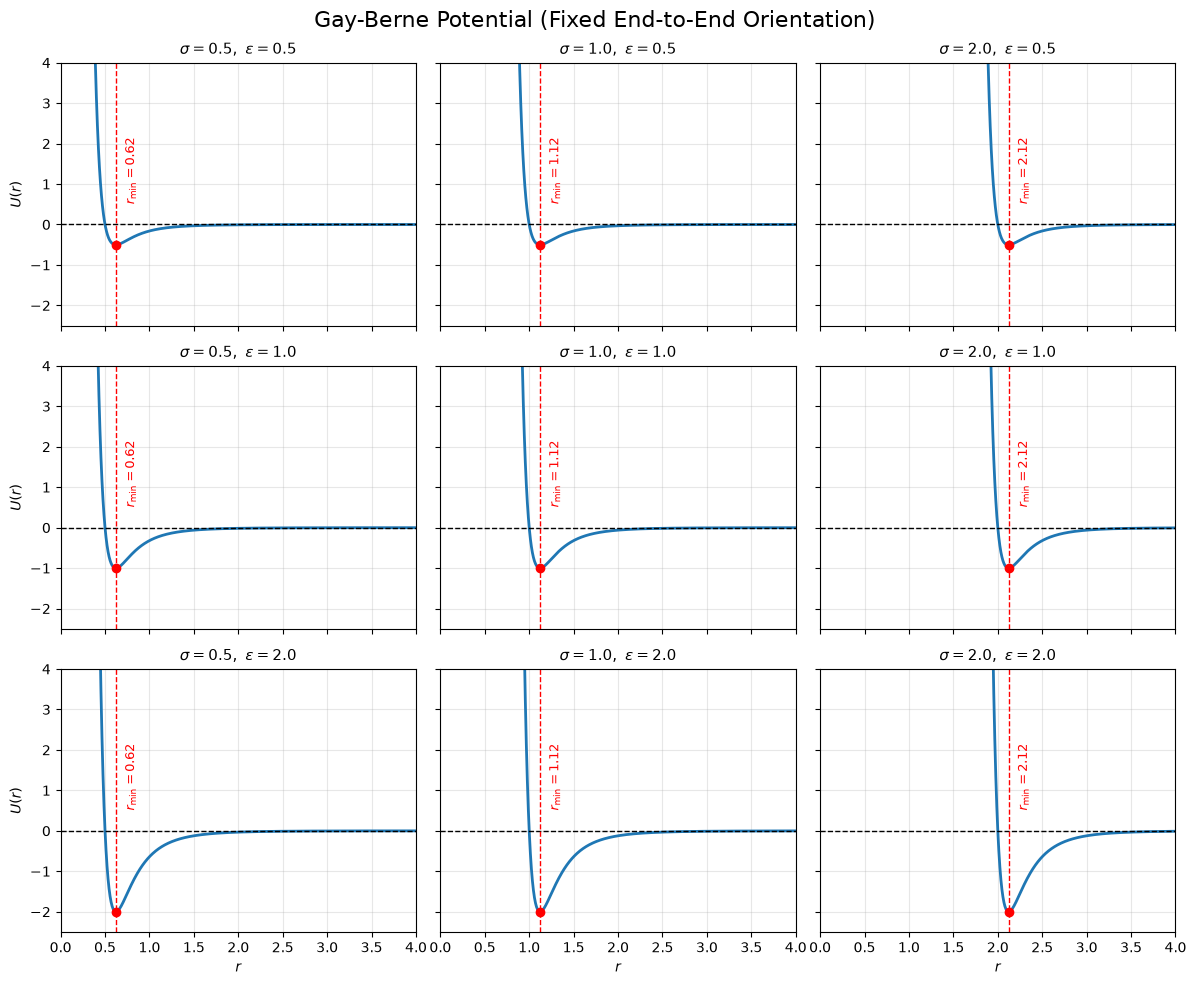

In [150]:
# Gay-Berne potential for a fixed orientation (end-to-end)
def gay_berne(r, sigma, epsilon, sigma0=1.0):
    R = r - sigma + sigma0
    return 4 * epsilon * ((sigma0 / R) ** 12 - (sigma0 / R) ** 6)


sigma_values = [0.5, 1.0, 2.0]
epsilon_values = [0.5, 1.0, 2.0]

r = np.linspace(0.3, 6.0, 1000)

fig, axes = plt.subplots(
    len(epsilon_values),
    len(sigma_values),
    figsize=(12, 10),
    sharex=True,
    sharey=True,
)

xlim = (0.0, 4.0)
ylim = (-2.5, 4.0)

sigma0 = 1.0

for i, epsilon in enumerate(epsilon_values):
    for j, sigma in enumerate(sigma_values):

        ax = axes[i, j]

        V = gay_berne(r, sigma, epsilon, sigma0)
        ax.plot(r, V, lw=2)

        # Analytical minimum
        r_min = sigma - sigma0 + 2 ** (1 / 6) * sigma0
        V_min = -epsilon

        ax.axhline(0, color="black", ls="--", lw=1)
        ax.axvline(r_min, color="red", ls="--", lw=1)

        ax.plot(r_min, V_min, "ro")

        ax.text(
            r_min + 0.1,
            0.5,
            rf"$r_{{\min}}={r_min:.2f}$",
            rotation=90,
            color="red",
            fontsize=9,
            ha="left",
            va="bottom",
        )

        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.grid(alpha=0.3)

        ax.set_title(
            rf"$\sigma={sigma},\ \epsilon={epsilon}$",
            fontsize=11,
        )

        if i == len(epsilon_values) - 1:
            ax.set_xlabel(r"$r$")

        if j == 0:
            ax.set_ylabel(r"$U(r)$")

fig.suptitle("Gay-Berne Potential (Fixed End-to-End Orientation)", fontsize=16)
plt.tight_layout()
plt.show()

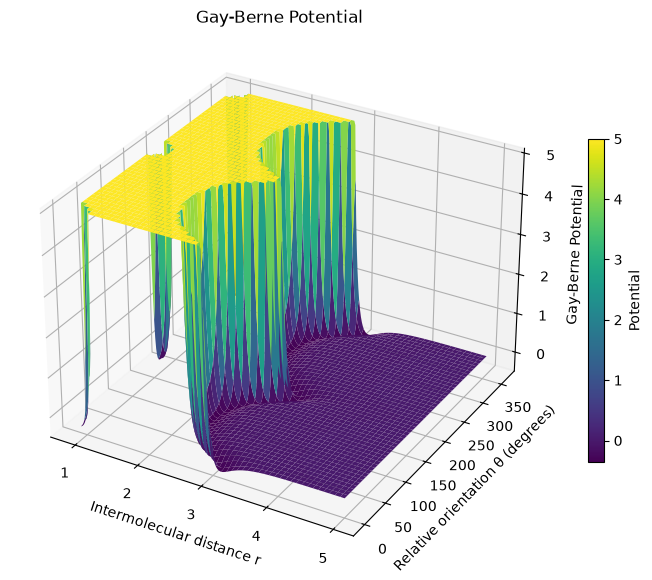

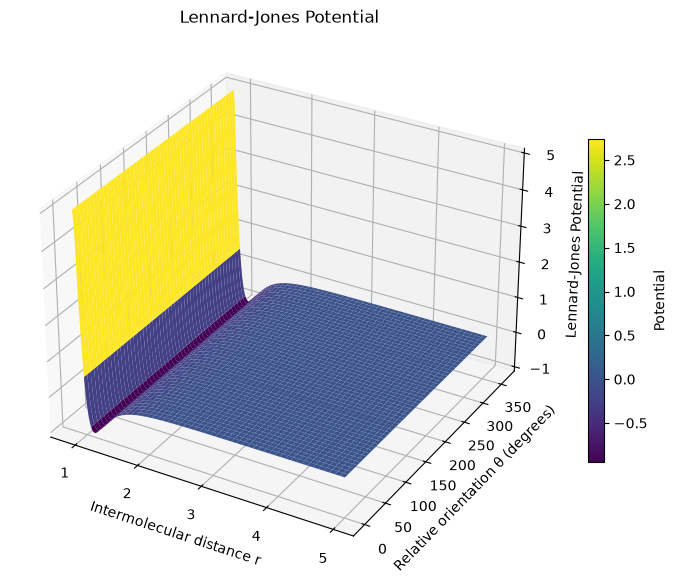

In [ ]:
theta = 0.0

r = np.linspace(0.9, 5.0, 250)
delta_phi = np.linspace(0, np.pi, 250)

R, DPHI = np.meshgrid(r, delta_phi)

U_GB = gay_berne_general_polar(R, theta, DPHI)
U_LJ = lennard_jones(R)

U_GB = np.clip(U_GB, -2, 5)
U_LJ = np.clip(U_LJ, -2, 5)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(R, DPHI * 180 / np.pi, U_GB, cmap="viridis", edgecolor="none")
ax.set_xlabel("Intermolecular distance r")
ax.set_ylabel("Relative orientation Δϕ (degrees)")
ax.set_zlabel("Gay-Berne Potential")

ax.set_title("Gay-Berne Potential")

fig.colorbar(surf, shrink=0.6, label="Potential")


fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(R, DPHI * 180 / np.pi, U_LJ, cmap="viridis", edgecolor="none")
ax.set_xlabel("Intermolecular distance r")
ax.set_ylabel("Relative orientation Δϕ (degrees)")
ax.set_zlabel("Lennard-Jones Potential")

ax.set_title("Lennard-Jones Potential")

fig.colorbar(surf, shrink=0.6, label="Potential")

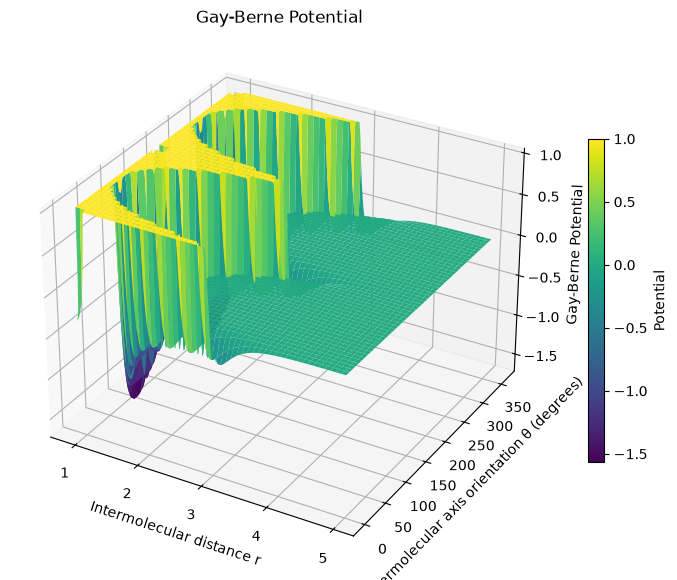

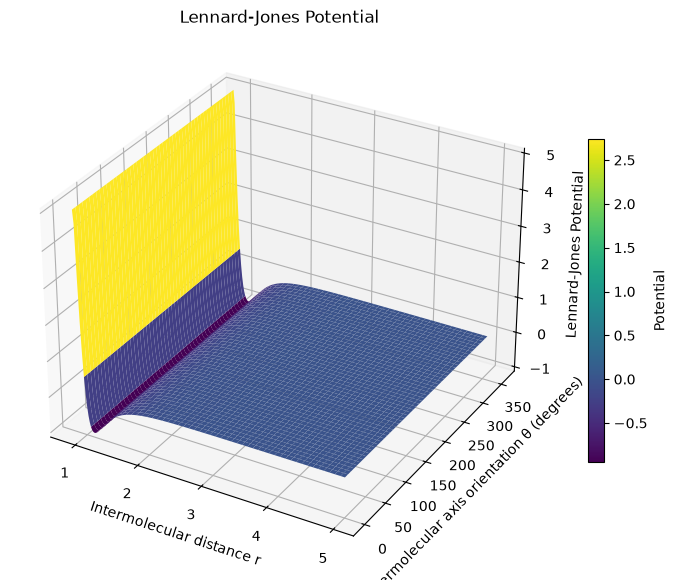

In [ ]:
delta_phi = 0.0

r = np.linspace(0.9, 5.0, 250)
theta = np.linspace(0, 2 * np.pi, 250)

R, THETA = np.meshgrid(r, theta)

U_GB = gay_berne_general_polar(R, THETA, delta_phi)
U_LJ = lennard_jones(R)

U_GB = np.clip(U_GB, -2, 1)  # clipped to be easy to see
U_LJ = np.clip(U_LJ, -2, 5)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(R, THETA * 180 / np.pi, U_GB, cmap="viridis", edgecolor="none")
ax.set_xlabel("Intermolecular distance r")
ax.set_ylabel("Intermolecular axis orientation θ (degrees)")
ax.set_zlabel("Gay-Berne Potential")

ax.set_title("Gay-Berne Potential")

fig.colorbar(surf, shrink=0.6, label="Potential")


fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(R, THETA * 180 / np.pi, U_LJ, cmap="viridis", edgecolor="none")
ax.set_xlabel("Intermolecular distance r")
ax.set_ylabel("Intermolecular axis orientation θ (degrees)")
ax.set_zlabel("Lennard-Jones Potential")

ax.set_title("Lennard-Jones Potential")

fig.colorbar(surf, shrink=0.6, label="Potential")

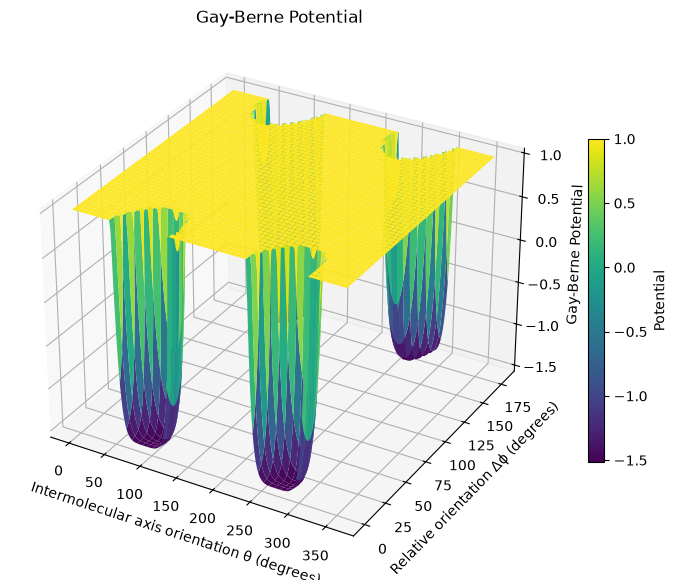

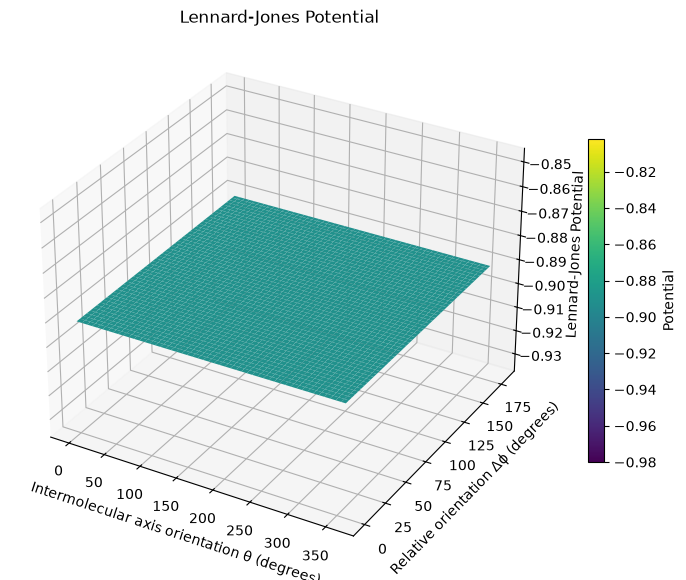

In [160]:
r = 1.2  # or r = 2**(1/6) for the LJ minimum

theta = np.linspace(0, 2 * np.pi, 250)
delta_phi = np.linspace(0, np.pi, 250)

THETA, DPHI = np.meshgrid(theta, delta_phi)

U_GB = gay_berne_general_polar(r, THETA, DPHI)
U_LJ = lennard_jones(r)

U_LJ = np.full_like(U_GB, U_LJ)

U_GB = np.clip(U_GB, -2, 1)  # clipped to be easy to see
U_LJ = np.clip(U_LJ, -2, 5)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    THETA * 180 / np.pi, DPHI * 180 / np.pi, U_GB, cmap="viridis", edgecolor="none"
)
ax.set_xlabel("Intermolecular axis orientation θ (degrees)")
ax.set_ylabel("Relative orientation Δϕ (degrees)")
ax.set_zlabel("Gay-Berne Potential")

ax.set_title("Gay-Berne Potential")

fig.colorbar(surf, shrink=0.6, label="Potential")


fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    THETA * 180 / np.pi, DPHI * 180 / np.pi, U_LJ, cmap="viridis", edgecolor="none"
)
ax.set_xlabel("Intermolecular axis orientation θ (degrees)")
ax.set_ylabel("Relative orientation Δϕ (degrees)")
ax.set_zlabel("Lennard-Jones Potential")

ax.set_title("Lennard-Jones Potential")

fig.colorbar(surf, shrink=0.6, label="Potential")

# Use cases / simulations

List of phenomena observable with Gay-Berne but not with Lennard-Jones:
- pi stacking (modelling rings as ellipsoids)
- liquid crystals: transition from amorphus phase to nematic and to smectic and maybe to crystalline phase (do it temperature-induced: while cooling)
- self-assembly of rods: same initial conditions but LJ creates droplets or random clusters, while GB creates chains and/or nematic domains
- crystal packing: compressing a system produces layered crystals or "orientationally-ordered" crystals
- vapor-liquid simulation: LJ produces spherical droplet while GB produces elongated droplet with aligned molecules at surface
- shear flow alignment: applying shear (cutting) to a system, LJ particles simply move, GB particles rotate and align with the flow
- diffusion anisotropy (?)
- others???


## Conclusions


## Bibliography

- Lennard-Jones potential: https://doi.org/10.1098/rspa.1924.0082
- Gay-Berne potential: https://doi.org/10.1063/1.441483
- LAMMPS Implementation of Gay-Berne: https://doi.org/10.1063/1.3058435
